In [12]:
# Extended Data Fig. 5a & 5b
# Load all necessary packages

library(tidyverse)
library(scales)
library(RColorBrewer)
library(treemapify)

# 调整图形输出尺寸（单位：英寸）
options(repr.plot.width = 14, repr.plot.height = 10)

In [5]:
# Data import and preview (Fig. 5a)

# Import time-series data for cumulative paper count
df_raw <- read_csv("/data/work/work_bigModel/paper/update/d_250810/paper_meta_match_v1_v2_250810_year_counts.csv")

# Quick preview of the raw data
glimpse(df_raw)
head(df_raw)

Rows: 126 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (2): PY, count

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 126
Columns: 2
$ PY    <dbl> 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910…
$ count <dbl> 12, 7, 14, 8, 13, 14, 11, 15, 21, 24, 13, 12, 22, 29, 33, 36, 39…


PY,count
<dbl>,<dbl>
1900,12
1901,7
1902,14
1903,8
1904,13
1905,14


In [6]:
# Data processing for cumulative line plot (Fig. 5a)
# Create full time series from 1900 to 2025 and compute cumulative count
df_full <- tibble(PY = 1900:2025) %>%
  left_join(df_raw, by = "PY") %>%
  mutate(count = replace_na(count, 0)) %>%
  arrange(PY) %>%
  mutate(cum_count = cumsum(count))

# Select data points at 10-year intervals (and include 2025)
df_bin_cumulative <- df_full %>%
  filter(PY %% 10 == 0 | PY == 2025) %>%
  arrange(PY)

# Show processed data
print(df_bin_cumulative, n = nrow(df_bin_cumulative))


# A tibble: 14 × 3
      PY  count cum_count
   <dbl>  <dbl>     <dbl>
 1  1900     12        12
 2  1910     13       152
 3  1920     42       480
 4  1930    243      1827
 5  1940    362      4703
 6  1950    804      9466
 7  1960   1468     20210
 8  1970   2589     50308
 9  1980  13771    130092
10  1990  23365    320446
11  2000  52810    733106
12  2010 123841   1630287
13  2020 259158   3452139
14  2025   7147   3964798


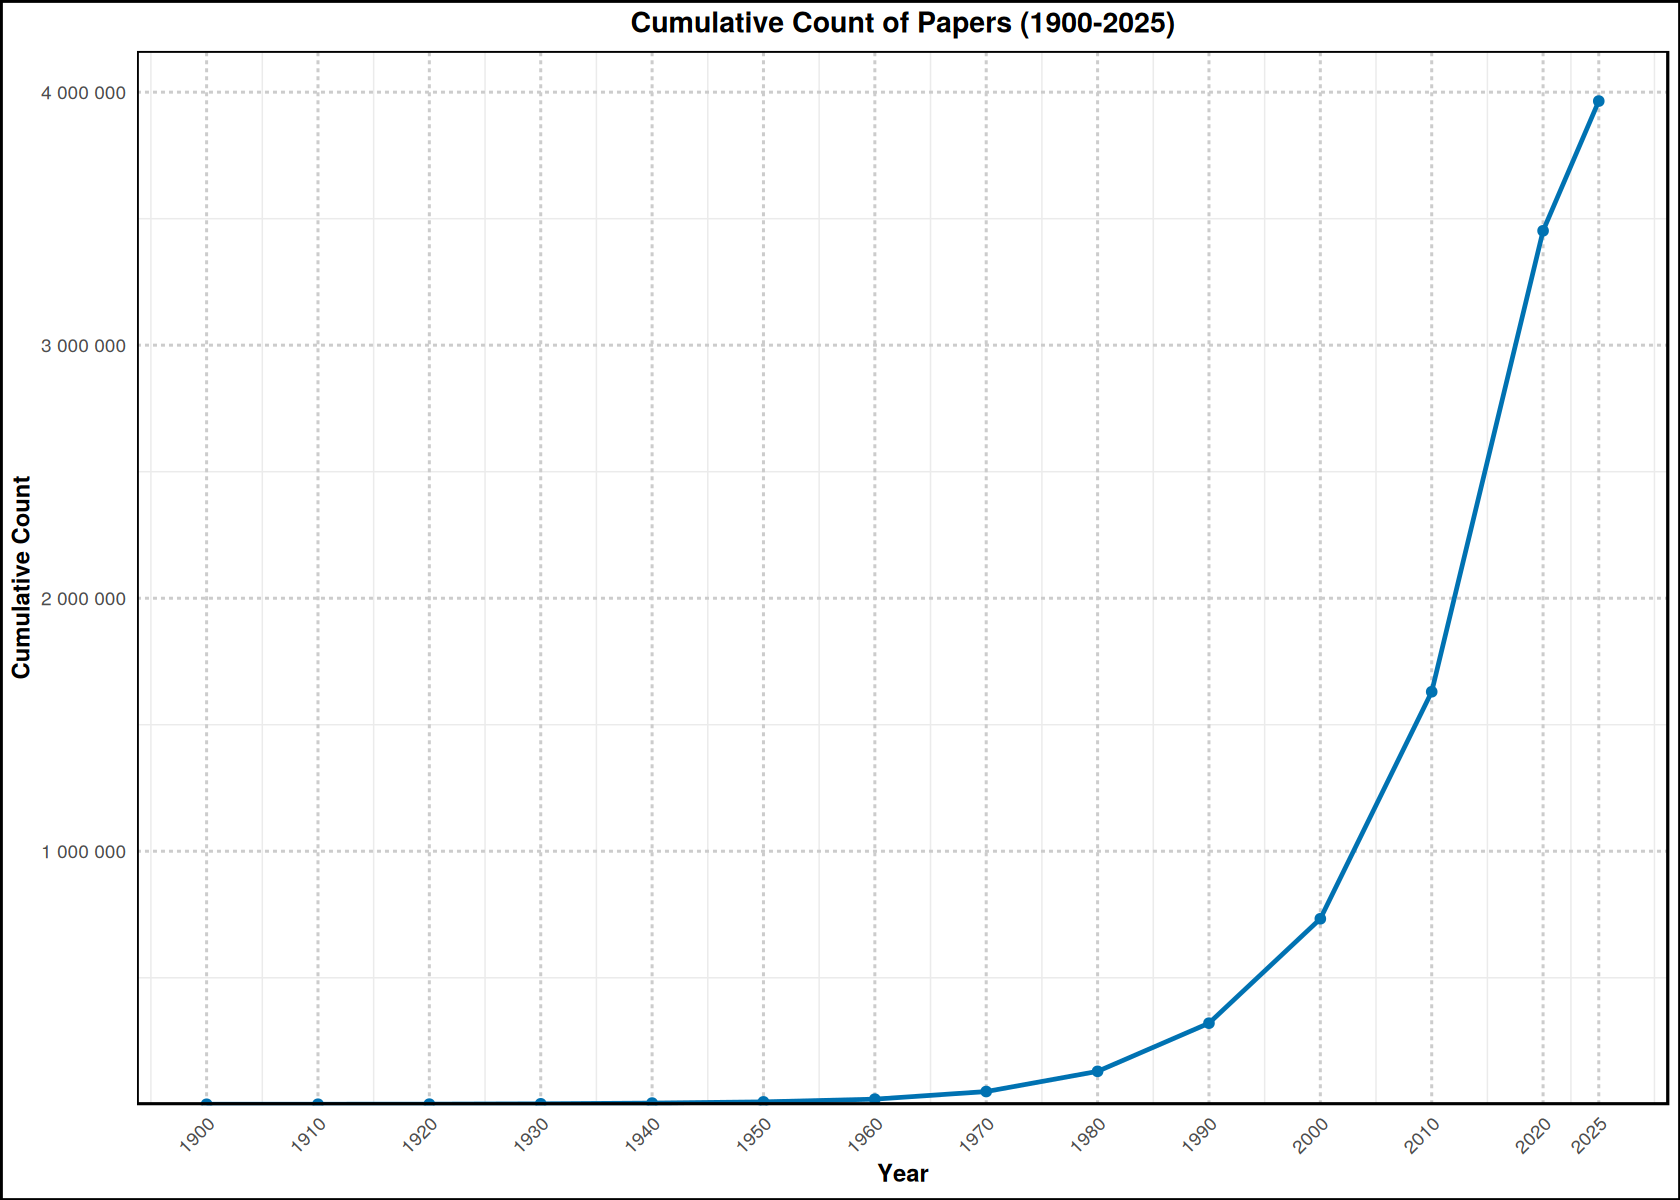

In [13]:
# Cumulative count line plot (Fig. 5a)
# Extended Data Fig. 5a: Cumulative count of papers over time
ggplot(df_bin_cumulative, aes(x = PY, y = cum_count, group = 1)) +
  geom_line(color = "#0072B2", linewidth = 1) +
  geom_point(color = "#0072B2", size = 2) +
  scale_x_continuous(
    breaks = df_bin_cumulative$PY,
    labels = df_bin_cumulative$PY,
    guide = guide_axis(angle = 45)
  ) +
  scale_y_continuous(
    labels = label_number(big.mark = " ", accuracy = 1),
    expand = expansion(mult = c(0, 0.05))
  ) +
  labs(
    title = "Cumulative Count of Papers (1900-2025)",
    x = "Year",
    y = "Cumulative Count"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
    plot.background = element_rect(colour = "black", fill = NA, linewidth = 1),
    plot.title = element_text(hjust = 0.5, face = "bold"),
    axis.title = element_text(face = "bold"),
    panel.grid.major = element_line(linetype = "dashed", color = "grey80")
  )

In [8]:
# Data import and preview (Fig. 5b)

# Import document type distribution data
merged_df <- read.csv("/data/work/work_bigModel/paper/update/plot/figure_s1/type_distribution_250616.csv", 
                      stringsAsFactors = FALSE)

# Preview data structure
glimpse(merged_df)
head(merged_df)

Rows: 2,924,537
Columns: 7
$ PT       <chr> "J", "J", "J", "J", "J", "J", "J", "J", "J", "J", "J", "J", "…
$ DI       <chr> "10.1614/WT-D-11-00052.1", "10.1093/gigascience/gix074", "10.…
$ WC       <chr> "Agronomy; Plant Sciences", "Biology; Multidisciplinary Scien…
$ SC       <chr> "Agriculture; Plant Sciences", "Life Sciences & Biomedicine -…
$ clean_TI <chr> "Effect of Drip-Applied Herbicides on Yellow Nutsedge ( i Cyp…
$ SC_first <chr> "Agriculture", "Life Sciences & Biomedicine - Other Topics", …
$ WC_first <chr> "Agronomy", "Biology", "Multidisciplinary Sciences", "Psychol…


,PT,DI,WC,SC,clean_TI,SC_first,WC_first
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,J,10.1614/WT-D-11-00052.1,Agronomy; Plant Sciences,Agriculture; Plant Sciences,Effect of Drip-Applied Herbicides on Yellow Nutsedge ( i Cyperus esculentus i ) in Plasticulture,Agriculture,Agronomy
2,J,10.1093/gigascience/gix074,Biology; Multidisciplinary Sciences,Life Sciences & Biomedicine - Other Topics; Science & Technology - Other Topics,Novel transcriptome resources for three scleractinian coral species from the Indo-Pacific,Life Sciences & Biomedicine - Other Topics,Biology
3,J,10.1126/science.adk6772,Multidisciplinary Sciences,Science & Technology - Other Topics,Metabolic loads and the costs of metazoan reproduction,Science & Technology - Other Topics,Multidisciplinary Sciences
4,J,10.1007/s12144-021-01506-z,"Psychology, Multidisciplinary",Psychology,Individuals' conceptions of COVID-19 pandemic through metaphor analysis,Psychology,"Psychology, Multidisciplinary"
5,J,10.1016/j.anireprosci.2023.107326,"Agriculture, Dairy & Animal Science; Reproductive Biology; Veterinary Sciences",Agriculture; Reproductive Biology; Veterinary Sciences,A soy lecithin nanoparticles-based extender effectively cryopreserves Holstein bull sperm,Agriculture,"Agriculture, Dairy & Animal Science"
6,J,10.1111/j.1476-5381.1991.tb09806.x,Pharmacology & Pharmacy,Pharmacology & Pharmacy,RESPONSE OF THE RAT MYOMETRIUM TO PHENYLEPHRINE IN EARLY-PREGNANCY AND THE EFFECTS OF 6-HYDROXYDOPAMINE,Pharmacology & Pharmacy,Pharmacology & Pharmacy


In [9]:
# Data preparation for treemap (Fig. 5b)

# Configuration parameters
use_col <- "SC_first"      # Column to analyze (change if needed)
top_n <- 30                # Number of top categories to display individually

# Check if column exists
if (!use_col %in% names(merged_df)) {
  stop(paste("Error: Column", use_col, "not found. Available columns:", 
             paste(names(merged_df), collapse = ", ")))
}

# Clean data: remove "- Other Topics" suffix and rename column
cleaned_df <- merged_df %>%
  mutate(!!sym(use_col) := gsub(" - Other Topics", "", .data[[use_col]], fixed = TRUE)) %>%
  rename(analysis_col = all_of(use_col)) %>%
  filter(!is.na(analysis_col) & analysis_col != "")

# Calculate category frequencies
type_counts_all <- cleaned_df %>%
  count(analysis_col) %>%
  arrange(desc(n))

# Keep top_n categories, aggregate the rest as "Others"
if (nrow(type_counts_all) > top_n) {
  top_counts <- type_counts_all[1:top_n, ]
  other_count <- data.frame(
    analysis_col = "Others",
    n = sum(type_counts_all$n[(top_n + 1):nrow(type_counts_all)])
  )
  type_counts <- bind_rows(top_counts, other_count)
} else {
  type_counts <- type_counts_all
}

# Calculate percentages and sort
type_counts <- type_counts %>%
  mutate(percentage = n / sum(n)) %>%
  arrange(desc(n))

# Display prepared frequency table
print(type_counts)


                           analysis_col      n  percentage
1      Biochemistry & Molecular Biology 434551 0.150894461
2                                Others 325683 0.113090893
3                           Agriculture 278378 0.096664599
4                        Plant Sciences 194820 0.067649733
5      Environmental Sciences & Ecology 188274 0.065376685
6                      Computer Science 169278 0.058780471
7                  Science & Technology 154612 0.053687817
8  Biotechnology & Applied Microbiology  99546 0.034566576
9                             Chemistry  94570 0.032838698
10                         Cell Biology  86799 0.030140279
11                             Oncology  82167 0.028531853
12                  Genetics & Heredity  78194 0.027152259
13                          Engineering  75017 0.026049071
14                         Microbiology  74744 0.025954274
15            Food Science & Technology  57013 0.019797322
16          Life Sciences & Biomedicine  48711 0.0169145

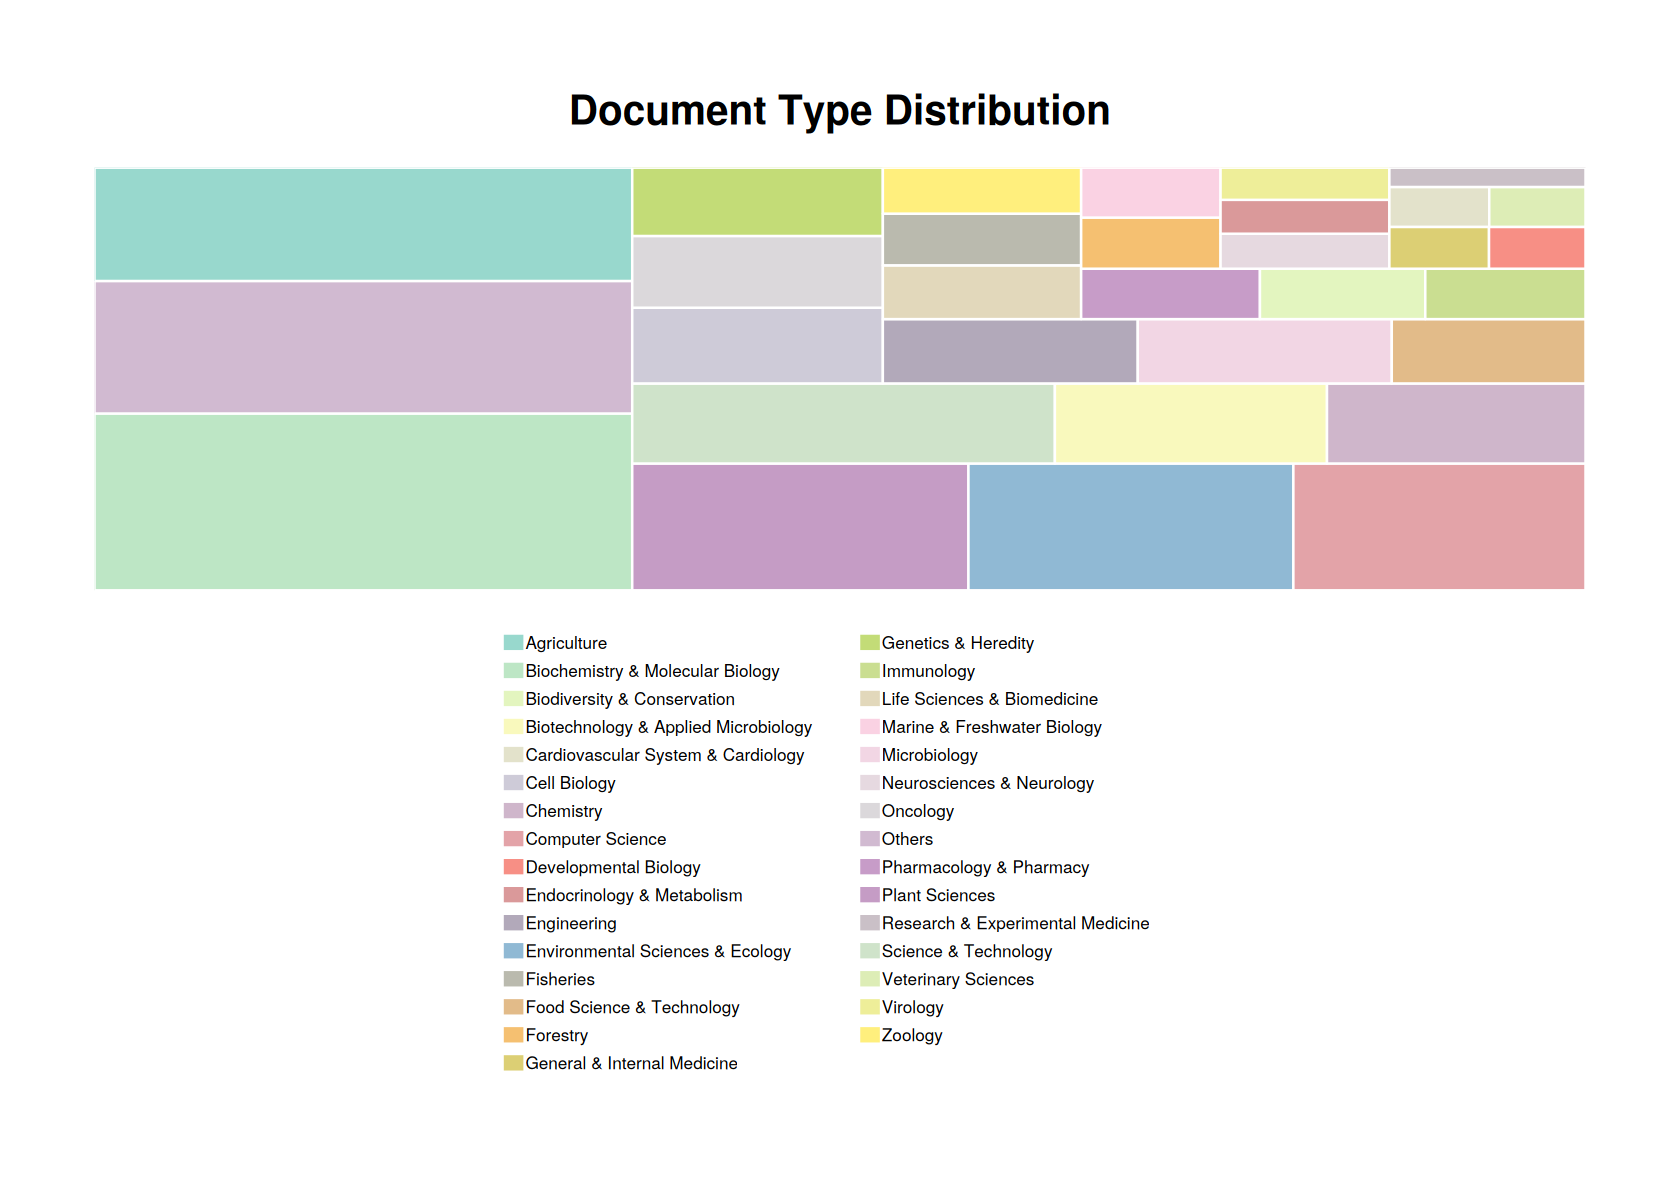

In [22]:
# Treemap of document type distribution (Fig. 5b)

# Extended Data Fig. 5b: Document type distribution as a treemap

n_types <- nrow(type_counts)
colors <- colorRampPalette(brewer.pal(min(n_types, 12), "Set3"))(n_types)

# Adjust legend layout based on number of categories
legend_cols <- ifelse(n_types > 30, 2, 1)
legend_font_size <- ifelse(n_types > 30, 10, 12)

ggplot(type_counts, aes(area = n, fill = analysis_col)) +
  geom_treemap(
    color = "white",
    size = 1.5,
    alpha = 0.9,
    layout = "squarified"
  ) +
  scale_fill_manual(
    name = "",
    values = colors,
    guide = guide_legend(
      ncol = legend_cols,
      keyheight = unit(0.4, "cm"),
      keywidth = unit(0.5, "cm")
    )
  ) +
  labs(
    title = "Document Type Distribution"
  ) +
  theme_void() +
  theme(
    plot.title = element_text(
      size = 24,
      face = "bold",
      hjust = 0.5,
      margin = margin(b = 20)
    ),
    plot.subtitle = element_text(
      size = 16,
      hjust = 0.5,
      margin = margin(b = 30)
    ),
    legend.position = "bottom",
    legend.box = "vertical",
    legend.title = element_text(
      size = 16,
      face = "bold",
      margin = margin(b = 10)
    ),
    legend.text = element_text(
      size = legend_font_size,
      margin = margin(r = 15)
    ),
    legend.margin = margin(t = 20, b = 20),
    plot.margin = margin(2, 2, 2, 2, "cm")
  )